<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Modulo2/Semana5/Dia3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Dia1

DIA 1: DATASETS, DIVISÃO TRIPLA E ANÁLISE EXPLORATÓRIA (EDA)

-> 1. Baixando e Extraindo o Dataset (Pedra, Papel e Tesoura)...
   O Dataset já está baixado e extraído!
[SUCESSO] Lendo dados da pasta: banco_de_imagens/rps
Classes encontradas: ['paper', 'scissors', 'rock']

-> 2. Análise Exploratória: O Dataset possui Viés?
 - A classe 'paper' possui 840 imagens.
 - A classe 'scissors' possui 840 imagens.
 - A classe 'rock' possui 840 imagens.


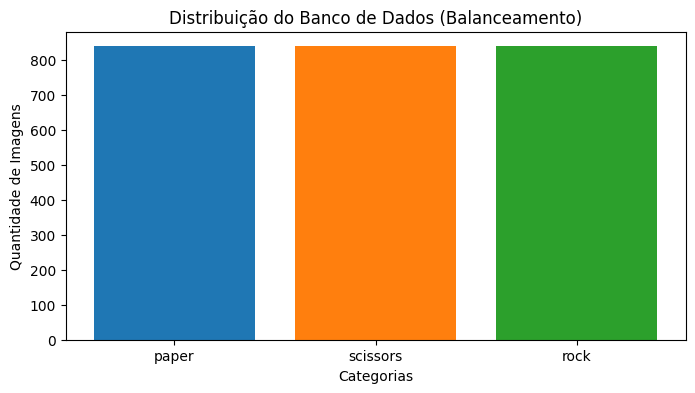


-> 3. Configurando Treino, Validação e TESTE...
Found 2520 files belonging to 3 classes.
Using 1764 files for training.
Found 2520 files belonging to 3 classes.
Using 756 files for validation.

[DIVISÃO CONCLUÍDA]
Lotes para Treino (80%): 56
Lotes para Validação (10%): 12
Lotes para Teste Cego (10%): 12

-> 4. Gerando Grade Visual do Lote de Treinamento...


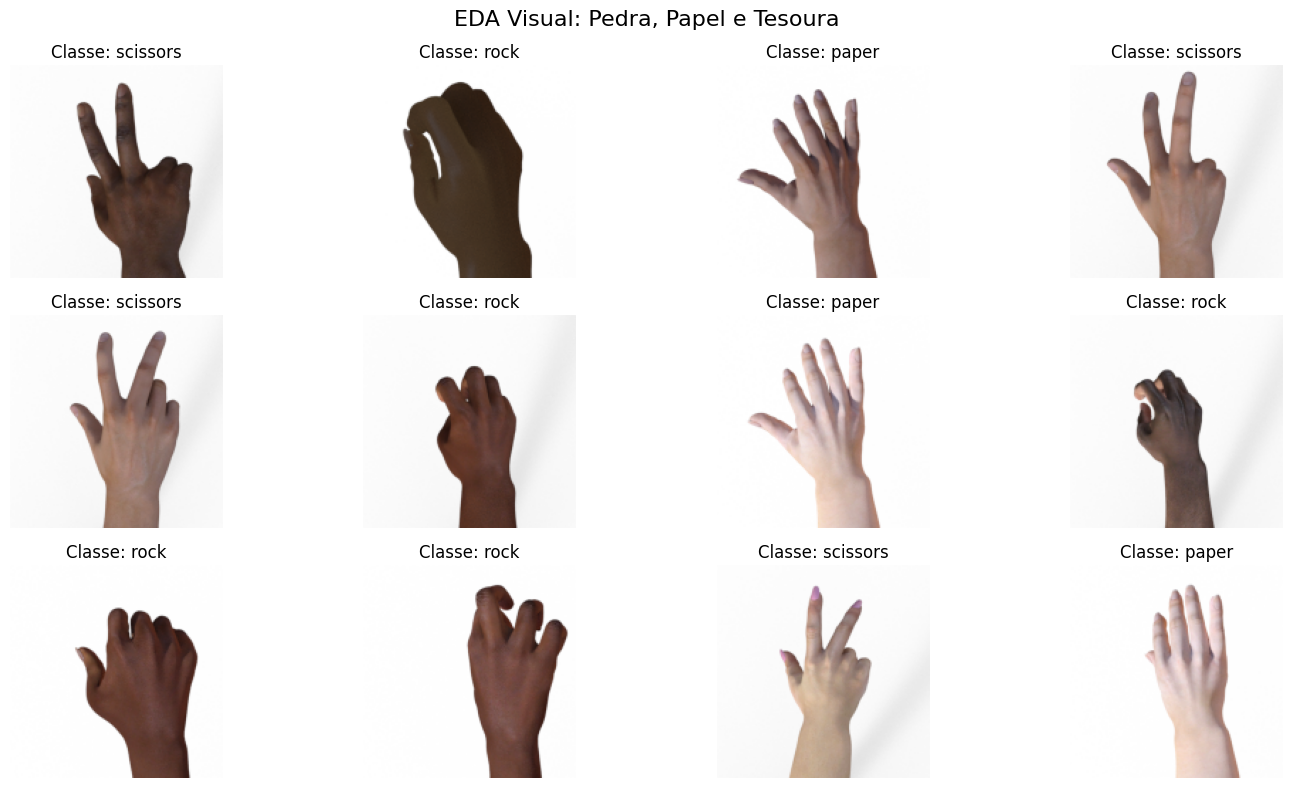

In [18]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
import urllib.request
import zipfile
import pathlib

print("="*75)
print("DIA 1: DATASETS, DIVISÃO TRIPLA E ANÁLISE EXPLORATÓRIA (EDA)")
print("="*75)

# ==============================================================================
# 1. DOWNLOAD VISÍVEL E EXTRAÇÃO SEGURA DE PASTAS
# ==============================================================================
print("\n-> 1. Baixando e Extraindo o Dataset (Pedra, Papel e Tesoura)...")

url_dataset = "https://storage.googleapis.com/download.tensorflow.org/data/rps.zip"
nome_zip = "rps.zip"
pasta_extracao = "banco_de_imagens"

# Verificamos se já não extraímos antes para não perder tempo baixando de novo
if not os.path.exists(pasta_extracao):
    print("   Baixando o arquivo .zip da internet...")
    urllib.request.urlretrieve(url_dataset, nome_zip)

    print("   Extraindo as imagens para a pasta visível do Colab...")
    with zipfile.ZipFile(nome_zip, 'r') as zip_ref:
        zip_ref.extractall(pasta_extracao)
else:
    print("   O Dataset já está baixado e extraído!")

# Definindo o caminho exato onde as imagens estão
pasta_raiz = pathlib.Path(pasta_extracao) / "rps"
subpastas = [f.name for f in pasta_raiz.iterdir() if f.is_dir()]

print(f"[SUCESSO] Lendo dados da pasta: {pasta_raiz}")
print(f"Classes encontradas: {subpastas}")


# ==============================================================================
# 2. EDA: ANÁLISE DE DISTRIBUIÇÃO (BALANCEAMENTO)
# ==============================================================================
print("\n-> 2. Análise Exploratória: O Dataset possui Viés?")

contagem_classes = []
for classe in subpastas:
    quantidade = len(list((pasta_raiz / classe).glob('*.png')))
    contagem_classes.append(quantidade)
    print(f" - A classe '{classe}' possui {quantidade} imagens.")

# Gráfico de Barras para a turma visualizar o balanço
plt.figure(figsize=(8, 4))
plt.bar(subpastas, contagem_classes, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title("Distribuição do Banco de Dados (Balanceamento)")
plt.ylabel("Quantidade de Imagens")
plt.xlabel("Categorias")
plt.show()


# ==============================================================================
# 3. PIPELINE DE INGESTÃO (O TRUQUE DA DIVISÃO TRIPLA)
# ==============================================================================
print("\n-> 3. Configurando Treino, Validação e TESTE...")
ALTURA_IMG, LARGURA_IMG = 150, 150
LOTE_SIZE = 32

# PASSO A: Tiramos 80% exclusivamente para o Treino
dados_treino = tf.keras.utils.image_dataset_from_directory(
  pasta_raiz,
  validation_split=0.3, # Vamos reservar 20% do total
  subset="training",    # Esta variável pega a parte majoritária (80%)
  seed=42,
  image_size=(ALTURA_IMG, LARGURA_IMG),
  batch_size=LOTE_SIZE
)

# PASSO B: Pegamos os 20% restantes (O Keras chama isso de Validation)
dados_reserva = tf.keras.utils.image_dataset_from_directory(
  pasta_raiz,
  validation_split=0.3,
  subset="validation",  # Esta variável pega os 20% reservados
  seed=42,
  image_size=(ALTURA_IMG, LARGURA_IMG),
  batch_size=LOTE_SIZE
)

nomes_oficiais = dados_treino.class_names

# PASSO C: A Mágica! Vamos fatiar os 20% da 'reserva' ao meio.
# Calculamos quantos "lotes" (batches) existem na reserva
total_lotes_reserva = tf.data.experimental.cardinality(dados_reserva).numpy()

# Dividimos pela metade (10% pro Simulado, 10% pra Prova Final)
lotes_val = total_lotes_reserva // 2

# take(): Pega a primeira metade para Validação
dados_val = dados_reserva.take(lotes_val)
# skip(): Pula a primeira metade e guarda a segunda para Teste Cego
dados_teste = dados_reserva.skip(lotes_val)

print(f"\n[DIVISÃO CONCLUÍDA]")
print(f"Lotes para Treino (80%): {tf.data.experimental.cardinality(dados_treino).numpy()}")
print(f"Lotes para Validação (10%): {tf.data.experimental.cardinality(dados_val).numpy()}")
print(f"Lotes para Teste Cego (10%): {tf.data.experimental.cardinality(dados_teste).numpy()}")

# Otimização de Leitura I/O na Memória RAM
AUTOTUNE = tf.data.AUTOTUNE
dados_treino = dados_treino.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
dados_val = dados_val.cache().prefetch(buffer_size=AUTOTUNE)
dados_teste = dados_teste.cache().prefetch(buffer_size=AUTOTUNE) # O teste também fica otimizado


# ==============================================================================
# 4. EDA VISUAL: COMO A CNN VAI ENXERGAR OS DADOS?
# ==============================================================================
print("\n-> 4. Gerando Grade Visual do Lote de Treinamento...")

plt.figure(figsize=(15, 8))
plt.suptitle("EDA Visual: Pedra, Papel e Tesoura", fontsize=16)

# Puxando apenas UM Lote (Batch) de 32 imagens
for imagens, rotulos in dados_treino.take(1):
  for i in range(12):
    ax = plt.subplot(3, 4, i + 1)

    # As imagens vêm como floats no Pipeline. Transformamos em Inteiro de 8bits (0 a 255)
    plt.imshow(imagens[i].numpy().astype("uint8"))

    nome_real = nomes_oficiais[rotulos[i]]
    plt.title(f"Classe: {nome_real}")
    plt.axis("off")

plt.tight_layout()
plt.show()

##Dia2

In [19]:
from tensorflow.keras import layers, Sequential

print("="*75)
print("DIA 2: ARQUITETURA CNN, DATA AUGMENTATION E COMPILAÇÃO")
print("="*75)

# ==============================================================================
# 1. BLOCO DE AUMENTO DE DADOS (DATA AUGMENTATION)
# ==============================================================================
print("\n-> 1. Configurando o Bloco de Data Augmentation...")

# EXPLICAÇÃO: Em vez de criarmos milhares de fotos falsas no HD, nós colocamos
# essas camadas DENTRO da Rede Neural. Cada vez que uma foto passar por aqui
# durante o treino, ela sofrerá uma leve mutação aleatória. Isso blinda o modelo!
data_augmentation = Sequential([
  layers.RandomFlip("horizontal", name="Giro_Aleatorio"),
  layers.RandomRotation(0.1, name="Rotacao_Aleatoria"), # Gira em até 10%
  layers.RandomZoom(0.1, name="Zoom_Aleatorio")         # Aproxima em até 10%
], name="Bloco_Augmentation")


# ==============================================================================
# 2. CONSTRUÇÃO DA REDE CONVOLUCIONAL (O CÉREBRO VISUAL)
# ==============================================================================
print("-> 2. Montando as Camadas da CNN...")

modelo_cnn = Sequential([
  # A. PORTA DE ENTRADA
  # Define o tamanho exato que a rede deve esperar: 150x150 com 3 canais de cor (RGB)
  layers.Input(shape=(150, 150, 3), name="Entrada_Imagem"),

  # B. PREPARAÇÃO E MUTAÇÃO
  data_augmentation,
  # Normalização: Esmaga os pixels de (0 a 255) para (0.0 a 1.0) facilitando a matemática
  layers.Rescaling(1./255, name="Normalizacao_Pixels"),

  # C. EXTRAÇÃO DE CARACTERÍSTICAS (VISÃO)
  # Bloco 1: Procura padrões básicos (linhas, bordas)
  layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu', name="Conv_1"),
  layers.MaxPooling2D(pool_size=(2, 2), name="Pooling_1"),

  # Bloco 2: Procura padrões médios (curvas, texturas)
  layers.Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu', name="Conv_2"),
  layers.MaxPooling2D(pool_size=(2, 2), name="Pooling_2"),

  # Bloco 3: Procura formas complexas (o formato exato dos dedos)
  layers.Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu', name="Conv_3"),
  layers.MaxPooling2D(pool_size=(2, 2), name="Pooling_3"),

  # D. ACHATAMENTO (A PONTE)
  # Transforma as dezenas de matrizes 2D mastigadas em uma única linha reta 1D
  layers.Flatten(name="Achatamento_Flatten"),

  # E. TOMADA DE DECISÃO (CÉREBRO)
  layers.Dense(128, activation='relu', name="Raciocinio_Denso"),

  layers.Dropout(0.5, name="Dropout_Regularizacao"),
  # F. O VEREDITO MULTICLASSE
  # REGRA: Temos 3 categorias (Pedra, Papel, Tesoura), logo 3 Neurônios e Softmax!
  layers.Dense(3, activation='softmax', name="Saida_Multiclasse")
])


# ==============================================================================
# 3. O RAIO-X: MATEMÁTICA E GEOMETRIA DA REDE
# ==============================================================================
print("\n" + "="*75)
print("ANÁLISE DO MODEL.SUMMARY() - O QUE ACONTECE COM A IMAGEM?")
print("="*75)
modelo_cnn.summary()

print("\n[DISCUSSÃO DA AULA - LEITURA DO SUMMARY]:")
print("1. Reparem na coluna 'Output Shape'.")
print("2. A entrada era 150x150. Após o 'Pooling_1', caiu para 75x75. Após o Pooling 3, caiu para 18x18.")
print("3. O Pooling comprimiu a foto, aliviando a memória da máquina sem perder a inteligência geométrica!")
print("4. O 'Flatten' pegou esses pedaços de 18x18x64 e os esticou, gerando um vetor de mais de 20.000 colunas.")
print("5. E vejam os Parâmetros: A rede terá que ajustar milhões de pesos matemáticos no Treinamento!")


# ==============================================================================
# 4. COMPILAÇÃO
# ==============================================================================
print("\n-> 3. Compilando o Modelo...")
# Como as nossas pastas foram convertidas em rótulos numéricos (0, 1 e 2) pelo pipeline
# do Keras no Dia 1, o Juiz correto AINDA É o sparse_categorical_crossentropy!
modelo_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("[SUCESSO] Arquitetura montada e compilada. Pronta para o treinamento amanhã!")

DIA 2: ARQUITETURA CNN, DATA AUGMENTATION E COMPILAÇÃO

-> 1. Configurando o Bloco de Data Augmentation...
-> 2. Montando as Camadas da CNN...

ANÁLISE DO MODEL.SUMMARY() - O QUE ACONTECE COM A IMAGEM?


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Bloco_Augmentation (Sequential) │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Normalizacao_Pixels (Rescaling) │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pooling_1 (MaxPooling2D)        │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pooling_2 (MaxPooling2D)        │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3 (Conv2D)                 │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pooling_3 (MaxPooling2D)        │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Achatamento_Flatten (Flatten)   │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Raciocinio_Denso (Dense)        │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Regularizacao (Dropout) │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Saida_Multiclasse (Dense)       │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,402,179 (20.61 MB)

 Trainable params: 5,402,179 (20.61 MB)

 Non-trainable params: 0 (0.00 B)


[DISCUSSÃO DA AULA - LEITURA DO SUMMARY]:
1. Reparem na coluna 'Output Shape'.
2. A entrada era 150x150. Após o 'Pooling_1', caiu para 75x75. Após o Pooling 3, caiu para 18x18.
3. O Pooling comprimiu a foto, aliviando a memória da máquina sem perder a inteligência geométrica!
4. O 'Flatten' pegou esses pedaços de 18x18x64 e os esticou, gerando um vetor de mais de 20.000 colunas.
5. E vejam os Parâmetros: A rede terá que ajustar milhões de pesos matemáticos no Treinamento!

-> 3. Compilando o Modelo...
[SUCESSO] Arquitetura montada e compilada. Pronta para o treinamento amanhã!


## Dia3

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("="*75)
print("DIA 3: TREINAMENTO, O TESTE CEGO E ANÁLISE DE LIMITAÇÕES")
print("="*75)

# ==============================================================================
# 1. O TREINAMENTO PESADO (MODEL.FIT)
# ==============================================================================
print("\n-> 1. Iniciando o Treinamento da CNN (Processamento via GPU)...")

# O Freio de Emergência: Se a Validação não melhorar por 4 épocas, ele para e restaura a melhor.
freio_emergencia = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

# A mágica acontece aqui! O Keras gerencia os lotes sozinho por causa dos nossos Datasets
historico = modelo_cnn.fit(
  dados_treino,
  validation_data=dados_val, # O Simulado a cada final de Época
  epochs=10, # 15 ou 20 para dar tempo de explicar durante a aula
  #callbacks=[freio_emergencia],
  verbose=1
)

DIA 3: TREINAMENTO, O TESTE CEGO E ANÁLISE DE LIMITAÇÕES

-> 1. Iniciando o Treinamento da CNN (Processamento via GPU)...
Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.4728 - loss: 1.0674 - val_accuracy: 0.7656 - val_loss: 0.5097
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.8424 - loss: 0.4078 - val_accuracy: 0.9714 - val_loss: 0.1196
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9388 - loss: 0.2001 - val_accuracy: 0.9870 - val_loss: 0.0557
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9450 - loss: 0.1652 - val_accuracy: 0.9948 - val_loss: 0.0277
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9677 - loss: 0.1161 - val_accuracy: 0.9974 - val_loss: 0.0167
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9717 - loss: 0.0836 - val_accuracy: 0.9974 - val_loss: 0.0226
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9580 - loss: 0.1338 - val_accuracy: 0.9974 - val_lo


-> 2. Plotando o Eletrocardiograma do Treino (Curvas de Erro)...


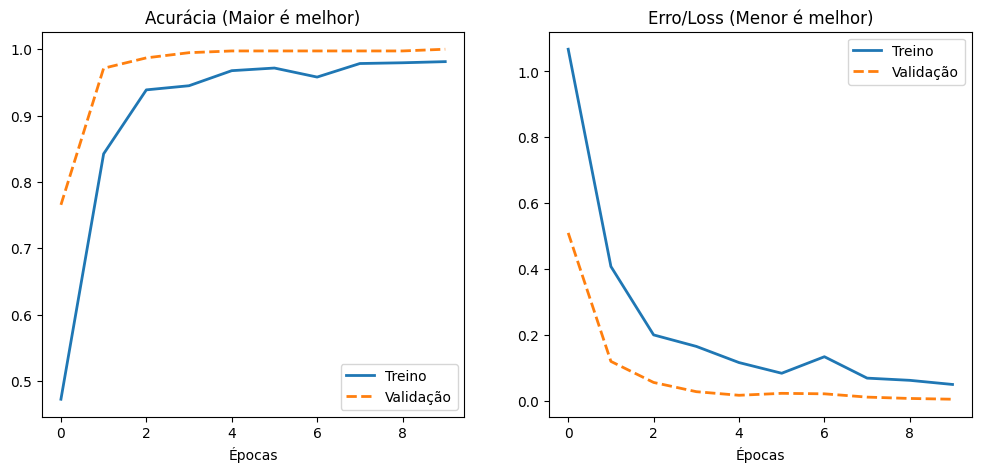

In [21]:
# ==============================================================================
# 2. DIAGNÓSTICO DE SAÚDE (CURVAS DE APRENDIZADO)
# ==============================================================================
print("\n-> 2. Plotando o Eletrocardiograma do Treino (Curvas de Erro)...")

plt.figure(figsize=(12, 5))

# Curva de Acurácia
plt.subplot(1, 2, 1)
plt.plot(historico.history['accuracy'], label='Treino', linewidth=2)
plt.plot(historico.history['val_accuracy'], label='Validação', linewidth=2, linestyle='--')
plt.title("Acurácia (Maior é melhor)")
plt.xlabel("Épocas")
plt.legend()

# Curva de Loss (Erro)
plt.subplot(1, 2, 2)
plt.plot(historico.history['loss'], label='Treino', linewidth=2)
plt.plot(historico.history['val_loss'], label='Validação', linewidth=2, linestyle='--')
plt.title("Erro/Loss (Menor é melhor)")
plt.xlabel("Épocas")
plt.legend()
plt.show()

In [22]:
# ==============================================================================
# 3. O TESTE CEGO (ABRINDO O COFRE DOS 10%)
# ==============================================================================
print("\n" + "="*75)
print("AVALIAÇÃO NO MUNDO REAL (DADOS NUNCA VISTOS PELA REDE)")
print("="*75)

# O evaluate julga a máquina na Prova Final
perda_teste, acuracia_teste = modelo_cnn.evaluate(dados_teste)
print(f"\n[VEREDITO FINAL]: A CNN atingiu {acuracia_teste * 100:.2f}% de acerto no Teste Cego!")


AVALIAÇÃO NO MUNDO REAL (DADOS NUNCA VISTOS PELA REDE)
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 1.0000 - loss: 0.0046

[VEREDITO FINAL]: A CNN atingiu 100.00% de acerto no Teste Cego!


In [23]:
# ==============================================================================
# 4. ALGORITMO CAÇADOR: EXTRAINDO PREDIÇÕES E FOTOS ERRADAS
# ==============================================================================
print("\n-> 3. Construindo a Matriz e caçando as imagens que enganaram a máquina...")

rotulos_reais = []
predicoes_finais = []

# Listas especiais para guardar exatamente as fotos que falharam
imagens_erradas = []
gabarito_dos_erros = []
chute_dos_erros = []

# Varremos o Dataset de Teste Cego lote por lote (batch por batch)
for imagens_lote, rotulos_lote in dados_teste:

    # 1. Pede para a CNN prever as 32 imagens do lote atual
    chutes_probabilidade = modelo_cnn.predict(imagens_lote, verbose=0)

    # 2. Transforma as porcentagens na classe vencedora (0, 1 ou 2) usando argmax
    chutes_classes = np.argmax(chutes_probabilidade, axis=1)

    # 3. Guarda tudo na lista gigante para a Matriz de Confusão
    rotulos_reais.extend(rotulos_lote.numpy())
    predicoes_finais.extend(chutes_classes)

    # 4. O CAÇADOR DE ERROS: Vasculhamos o lote para achar divergências
    for i in range(len(rotulos_lote)):
        if rotulos_lote[i].numpy() != chutes_classes[i]:
            # Se o Gabarito for diferente do Chute, guardamos a foto como prova do crime!
            imagens_erradas.append(imagens_lote[i].numpy())
            gabarito_dos_erros.append(rotulos_lote[i].numpy())
            chute_dos_erros.append(chutes_classes[i])


-> 3. Construindo a Matriz e caçando as imagens que enganaram a máquina...



-> 4. Matriz de Confusão Industrial:
              precision    recall  f1-score   support

       paper       1.00      1.00      1.00       122
        rock       1.00      1.00      1.00       129
    scissors       1.00      1.00      1.00       121

    accuracy                           1.00       372
   macro avg       1.00      1.00      1.00       372
weighted avg       1.00      1.00      1.00       372



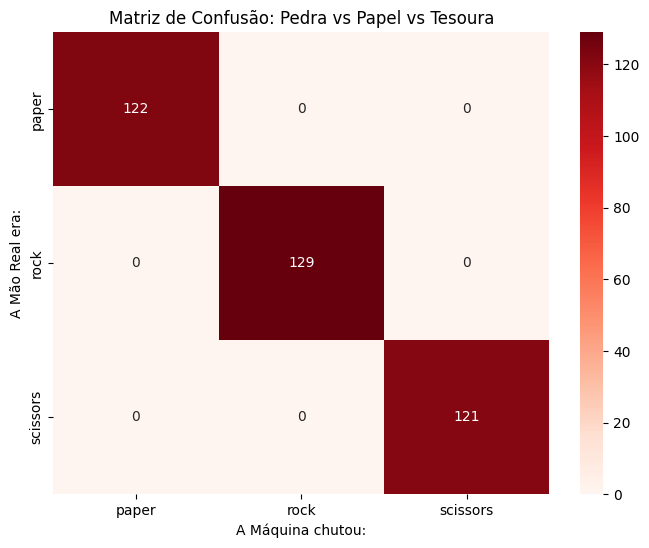

In [24]:
# ==============================================================================
# 5. MATRIZ DE CONFUSÃO (3X3) E RELATÓRIO TÉCNICO
# ==============================================================================
print("\n-> 4. Matriz de Confusão Industrial:")
print(classification_report(rotulos_reais, predicoes_finais, target_names=nomes_oficiais))

plt.figure(figsize=(8, 6))
matriz = confusion_matrix(rotulos_reais, predicoes_finais)
sns.heatmap(matriz, annot=True, fmt='d', cmap='Reds', # Vermelho para alerta de erros
            xticklabels=nomes_oficiais, yticklabels=nomes_oficiais)
plt.title("Matriz de Confusão: Pedra vs Papel vs Tesoura")
plt.ylabel("A Mão Real era:")
plt.xlabel("A Máquina chutou:")
plt.show()

In [25]:
# ==============================================================================
# 6. JULGAMENTO HUMANO: ANALISANDO AS LIMITAÇÕES DA CNN
# ==============================================================================
print("\n" + "="*75)
print("AUDITORIA DE ERROS: POR QUE A MÁQUINA SE CONFUNDIU?")
print("="*75)
print(f"Total de mãos interpretadas incorretamente: {len(imagens_erradas)}")

if len(imagens_erradas) > 0:
    print("Abaixo, uma amostra fotográfica dos erros graves do modelo:")

    # Define quantas imagens de erro vamos mostrar (máximo de 8 para não estourar a tela)
    limite_exibicao = min(8, len(imagens_erradas))

    plt.figure(figsize=(15, 7))
    for i in range(limite_exibicao):
        ax = plt.subplot(2, 4, i + 1)

        # Converte a foto (que é float) para Inteiro antes de exibir
        foto = imagens_erradas[i].astype("uint8")
        plt.imshow(foto)

        texto_real = nomes_oficiais[gabarito_dos_erros[i]]
        texto_chute = nomes_oficiais[chute_dos_erros[i]]

        plt.title(f"Real: {texto_real}\nChutou: {texto_chute}", color="red", fontweight="bold")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("\n[DISCUSSÃO DA AULA]: Turma, avaliem as imagens acima.")
    print("- A mão estava muito próxima da câmera?")
    print("- Fazer 'Tesoura' de lado parece com fazer 'Pedra' de frente?")
    print("Conclusão: Avaliar as métricas no Excel é fácil. O verdadeiro Engenheiro de IA")
    print("abre as fotos que a rede errou e procura o erro no posicionamento da câmera!")
else:
    print("\nQue incrível! O modelo acertou 100% no Teste Cego. Não houve erros para exibir.")


AUDITORIA DE ERROS: POR QUE A MÁQUINA SE CONFUNDIU?
Total de mãos interpretadas incorretamente: 0

Que incrível! O modelo acertou 100% no Teste Cego. Não houve erros para exibir.


## Cortando dados


EXPERIMENTO DIDÁTICO: A MÁQUINA COM FOME DE DADOS (OVERFITTING)
-> 1. Clonando a arquitetura para resetar o 'cérebro' da máquina...
-> 2. Sabotando o Dataset: Entregando apenas 3 lotes (96 imagens) para o treino!
-> 3. Treinando o modelo (Sem freio de emergência para forçar a memorização)...
Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 285ms/step - accuracy: 0.4167 - loss: 2.3493 - val_accuracy: 0.3307 - val_loss: 1.5029
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.3438 - loss: 1.4300 - val_accuracy: 0.3307 - val_loss: 1.1125
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.3854 - loss: 1.0993 - val_accuracy: 0.3307 - val_loss: 1.0966
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.2604 - loss: 1.0954 - val_accuracy: 0.3385 - val_loss: 1.0886
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.3438 - loss: 1.1018 - val_accuracy: 0.3672 - val_loss: 1.0840
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.3333 - loss: 1.

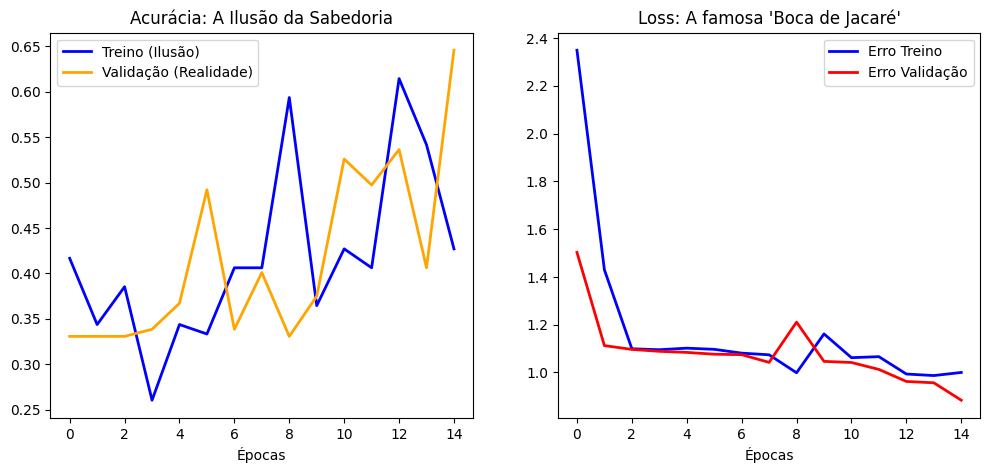


-> 5. Rodando o modelo viciado contra o Teste Cego...
Acurácia Desastrosa no mundo real: 63.44%


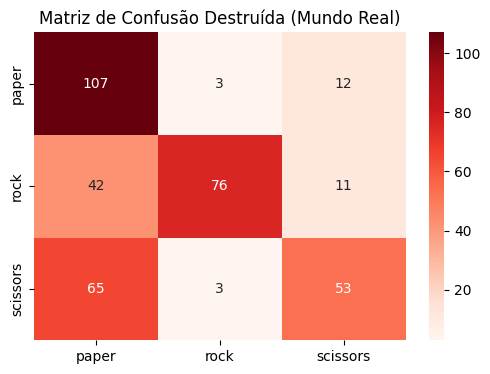

In [36]:
print("\n" + "="*75)
print("EXPERIMENTO DIDÁTICO: A MÁQUINA COM FOME DE DADOS (OVERFITTING)")
print("="*75)

# ==============================================================================
# 1. A SABOTAGEM (CRIANDO UM MODELO NOVO E CORTANDO OS DADOS)
# ==============================================================================
print("-> 1. Clonando a arquitetura para resetar o 'cérebro' da máquina...")
# clone_model cria uma cópia exata da sua CNN, mas com pesos zerados (burra novamente)
modelo_fome = tf.keras.models.clone_model(modelo_cnn)
modelo_fome.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("-> 2. Sabotando o Dataset: Entregando apenas 3 lotes (96 imagens) para o treino!")
# take(3) pega apenas os 3 primeiros lotes e descarta o resto das milhares de imagens
dados_treino_sabotado = dados_treino.take(3)

# ==============================================================================
# 2. TREINAMENTO VICIADO
# ==============================================================================
print("-> 3. Treinando o modelo (Sem freio de emergência para forçar a memorização)...")
# Note que removemos o Early Stopping de propósito!
historico_fome = modelo_fome.fit(
    dados_treino_sabotado,
    validation_data=dados_val,
    epochs=15, # Deixamos rodar bastante para ela decorar perfeitamente as 96 fotos
    verbose=1  # verbose=0 para não poluir a tela com a barra de progresso agora
)
print("[CONCLUÍDO] O modelo decorou as 96 fotos!")

# ==============================================================================
# 3. O DIAGNÓSTICO DO DESASTRE (A BOCA DE JACARÉ)
# ==============================================================================
print("\n-> 4. O Eletrocardiograma do Overfitting:")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(historico_fome.history['accuracy'], label='Treino (Ilusão)', color='blue', linewidth=2)
plt.plot(historico_fome.history['val_accuracy'], label='Validação (Realidade)', color='orange', linewidth=2)
plt.title("Acurácia: A Ilusão da Sabedoria")
plt.xlabel("Épocas")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(historico_fome.history['loss'], label='Erro Treino', color='blue', linewidth=2)
plt.plot(historico_fome.history['val_loss'], label='Erro Validação', color='red', linewidth=2)
plt.title("Loss: A famosa 'Boca de Jacaré'")
plt.xlabel("Épocas")
plt.legend()
plt.show()

# ==============================================================================
# 5. O CHOQUE NO TESTE CEGO
# ==============================================================================
print("\n-> 5. Rodando o modelo viciado contra o Teste Cego...")
perda_ruim, acuracia_ruim = modelo_fome.evaluate(dados_teste, verbose=0)
print(f"Acurácia Desastrosa no mundo real: {acuracia_ruim * 100:.2f}%")

# Extraindo matriz rápida só para provar o caos
rotulos_reais_ruim = []
chutes_ruins = []

for img_lote, rot_lote in dados_teste:
    probs = modelo_fome.predict(img_lote, verbose=0)
    chutes = np.argmax(probs, axis=1)
    rotulos_reais_ruim.extend(rot_lote.numpy())
    chutes_ruins.extend(chutes)

plt.figure(figsize=(6, 4))
matriz_ruim = confusion_matrix(rotulos_reais_ruim, chutes_ruins)
sns.heatmap(matriz_ruim, annot=True, fmt='d', cmap='Reds', xticklabels=nomes_oficiais, yticklabels=nomes_oficiais)
plt.title("Matriz de Confusão Destruída (Mundo Real)")
plt.show()

## Descobrindo imagem aleatoria

TIRA-TEIMA: O TESTE DA ÚNICA FOTO ENTRE OS DOIS MODELOS


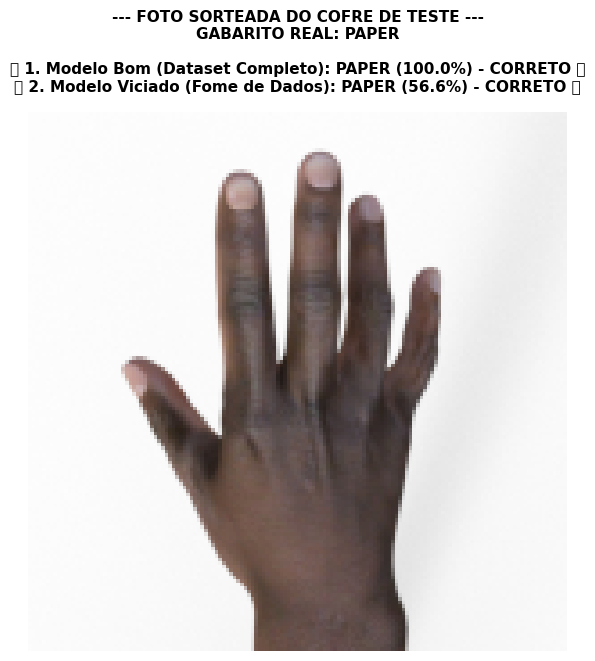


[ANÁLISE DO PROFESSOR]:
- A mão real é: paper
- O modelo com dados suficientes votou em: paper (100.0% de certeza)
- O modelo sem dados votou em: paper (56.6% de certeza)


In [41]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("="*75)
print("TIRA-TEIMA: O TESTE DA ÚNICA FOTO ENTRE OS DOIS MODELOS")
print("="*75)

# ==============================================================================
# 1. CAPTURANDO UMA FOTO ALEATÓRIA DO COFRE DE TESTE CEGO
# ==============================================================================
# Pegamos o primeiro lote (batch) do nosso dataset de teste
for imagens_lote, rotulos_lote in dados_teste.take(1):

    # Escolha o índice da foto no lote (experimente mudar de 0 para 5, 10, 15...)
    indice_escolhido = 10

    # A imagem crua para exibir no Matplotlib (convertida para Inteiro 8-bits)
    imagem_para_mostrar = imagens_lote[indice_escolhido].numpy().astype("uint8")

    # O gabarito real da mão
    id_real = rotulos_lote[indice_escolhido].numpy()
    gabarito_real = nomes_oficiais[id_real]

    # Expandimos a dimensão para o formato que a CNN exige: (1, 150, 150, 3)
    imagem_expandida = tf.expand_dims(imagens_lote[indice_escolhido], axis=0)

# ==============================================================================
# 2. PERGUNTANDO AOS DOIS CÉREBROS
# ==============================================================================

# A. O Modelo Bom (Geral e bem treinado)
prob_bom = modelo_cnn.predict(imagem_expandida, verbose=0)
classe_bom = np.argmax(prob_bom[0])
confianca_bom = np.max(prob_bom[0]) * 100
chute_bom = nomes_oficiais[classe_bom]

# B. O Modelo Viciado (Aquele que sofreu com a Fome de Dados / Overfitting)
prob_fome = modelo_fome.predict(imagem_expandida, verbose=0)
classe_fome = np.argmax(prob_fome[0])
confianca_fome = np.max(prob_fome[0]) * 100
chute_fome = nomes_oficiais[classe_fome]

# ==============================================================================
# 3. RENDERIZAÇÃO COMPARATIVA NA TELA
# ==============================================================================
plt.figure(figsize=(7, 7))
plt.imshow(imagem_para_mostrar)
plt.axis("off")

# Definindo cores visuais baseadas no acerto
status_bom = "CORRETO 🟢" if chute_bom == gabarito_real else "ERROU 🔴"
status_fome = "CORRETO 🟢" if chute_fome == gabarito_real else "ERROU 🔴"

# Montando o texto do painel dinâmico
titulo_formatado = (
    f"--- FOTO SORTEADA DO COFRE DE TESTE ---\n"
    f"GABARITO REAL: {gabarito_real.upper()}\n\n"
    f"🤖 1. Modelo Bom (Dataset Completo): {chute_bom.upper()} ({confianca_bom:.1f}%) - {status_bom}\n"
    f"🤡 2. Modelo Viciado (Fome de Dados): {chute_fome.upper()} ({confianca_fome:.1f}%) - {status_fome}"
)

plt.title(titulo_formatado, fontsize=11, fontweight="bold", pad=15)
plt.show()

print(f"\n[ANÁLISE DO PROFESSOR]:")
print(f"- A mão real é: {gabarito_real}")
print(f"- O modelo com dados suficientes votou em: {chute_bom} ({confianca_bom:.1f}% de certeza)")
print(f"- O modelo sem dados votou em: {chute_fome} ({confianca_fome:.1f}% de certeza)")

## Descobrindo imagens reais

TESTE DE FOGO: INFERÊNCIA NO MUNDO REAL (FOTOS DO PROFESSOR)
-> Processando as fotos fora do laboratório...


/tmp/ipykernel_2538/3556281725.py:70: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2538/3556281725.py:70: UserWarning: Glyph 129313 (\N{CLOWN FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


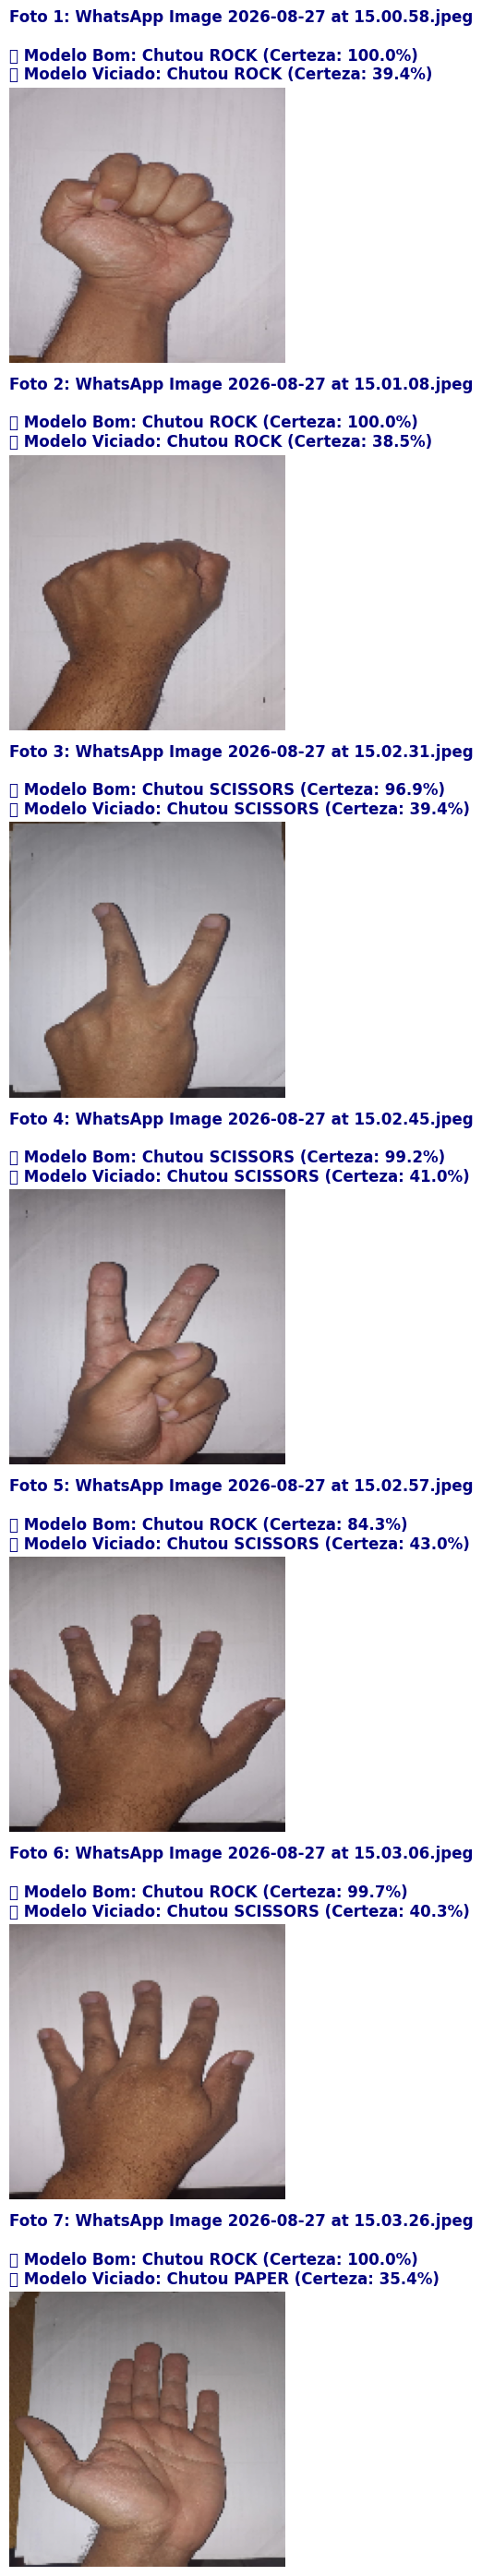


[DISCUSSÃO DA AULA]:
O modelo de 100% acertou as fotos do professor? Se errou, não se assustem!
Isso se chama 'Data Shift' (Deslocamento de Dados). A rede foi treinada com
mãos de CGI (videogame) perfeitamente brancas, e testada em mãos humanas
com sombras e pelos. A lição de hoje: O dataset DEVE refletir o mundo real!


In [38]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os

print("="*75)
print("TESTE DE FOGO: INFERÊNCIA NO MUNDO REAL (FOTOS DO PROFESSOR)")
print("="*75)

# Lista com os nomes exatos dos arquivos que você fez upload
fotos_reais = [
    "WhatsApp Image 2026-08-27 at 15.00.58.jpeg", # Pedra (Frente)
    "WhatsApp Image 2026-08-27 at 15.01.08.jpeg", # Pedra (Costas)
    "WhatsApp Image 2026-08-27 at 15.02.31.jpeg", # Tesoura (Frente)
    "WhatsApp Image 2026-08-27 at 15.02.45.jpeg", # Tesoura (Frente 2)
    "WhatsApp Image 2026-08-27 at 15.02.57.jpeg", # Papel (Costas)
    "WhatsApp Image 2026-08-27 at 15.03.06.jpeg", # Papel (Costas 2)
    "WhatsApp Image 2026-08-27 at 15.03.26.jpeg"  # Papel (Frente)
]

# Configurando o painel gráfico
fig, ax = plt.subplots(len(fotos_reais), 1, figsize=(6, 4 * len(fotos_reais)))
if len(fotos_reais) == 1: ax = [ax] # Tratamento caso seja só 1 foto

print("-> Processando as fotos fora do laboratório...")

for i, nome_arquivo in enumerate(fotos_reais):
    if not os.path.exists(nome_arquivo):
        print(f"[ERRO] A foto {nome_arquivo} não foi encontrada. Fez o upload?")
        continue

    # 1. Carregando e formatando a imagem do jeito que a CNN exige (150x150 RGB)
    img_bruta = tf.keras.utils.load_img(nome_arquivo, target_size=(150, 150))

    # Transformando a imagem em matriz numérica
    img_array = tf.keras.utils.img_to_array(img_bruta)

    # Expandindo a dimensão para simular um lote de 1 imagem (1, 150, 150, 3)
    img_tensor = tf.expand_dims(img_array, 0)

    # ==========================================================================
    # 2. O JULGAMENTO DAS MÁQUINAS
    # ==========================================================================

    # A. O Modelo Bom (Treinado com 100% da base CGI)
    probs_bom = modelo_cnn.predict(img_tensor, verbose=0)
    chute_bom = nomes_oficiais[np.argmax(probs_bom[0])]
    confianca_bom = np.max(probs_bom[0]) * 100

    # B. O Modelo com Fome de Dados (Apenas 96 fotos CGI)
    probs_fome = modelo_fome.predict(img_tensor, verbose=0)
    chute_fome = nomes_oficiais[np.argmax(probs_fome[0])]
    confianca_fome = np.max(probs_fome[0]) * 100

    # ==========================================================================
    # 3. RENDERIZAÇÃO
    # ==========================================================================
    ax[i].imshow(img_bruta)
    ax[i].axis("off")

    texto_resultado = (
        f"Foto {i+1}: {nome_arquivo}\n\n"
        f"🤖 Modelo Bom: Chutou {chute_bom.upper()} (Certeza: {confianca_bom:.1f}%)\n"
        f"🤡 Modelo Viciado: Chutou {chute_fome.upper()} (Certeza: {confianca_fome:.1f}%)"
    )

    # Pintamos o texto de azul escuro para destacar
    ax[i].set_title(texto_resultado, loc='left', color='navy', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n[DISCUSSÃO DA AULA]:")
print("O modelo de 100% acertou as fotos do professor? Se errou, não se assustem!")
print("Isso se chama 'Data Shift' (Deslocamento de Dados). A rede foi treinada com")
print("mãos de CGI (videogame) perfeitamente brancas, e testada em mãos humanas")
print("com sombras e pelos. A lição de hoje: O dataset DEVE refletir o mundo real!")

## Exemplo de como a imagem fica no treinamento

O VERDADEIRO RAIO-X: EXTRAÇÃO DIRETA DO MODELO (API FUNCIONAL)


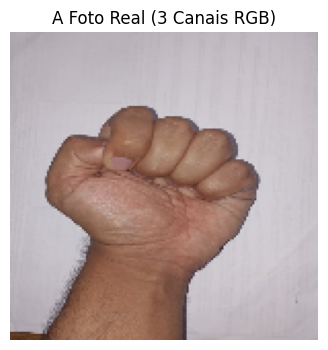


[CAMADA CONV2D_1] O tensor possui o formato geométrico: (1, 150, 150, 16)
A rede pegou a cor e separou em 16 mapas de características diferentes:


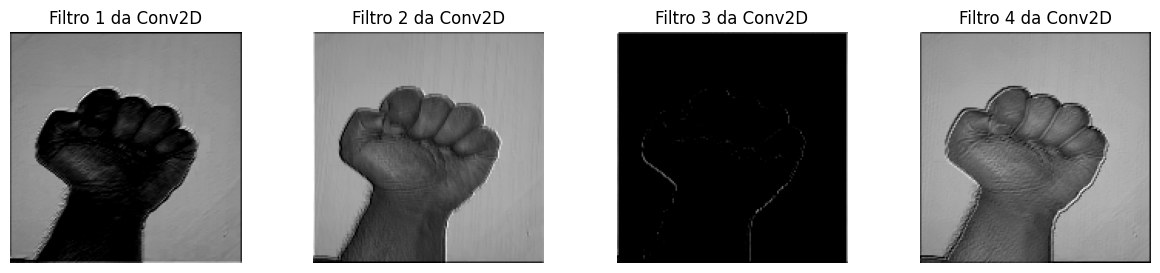


[CAMADA POOLING_1] O tensor encolheu para: (1, 75, 75, 16)
A imagem perdeu nitidez e caiu pela metade, mas a inteligência continuou:


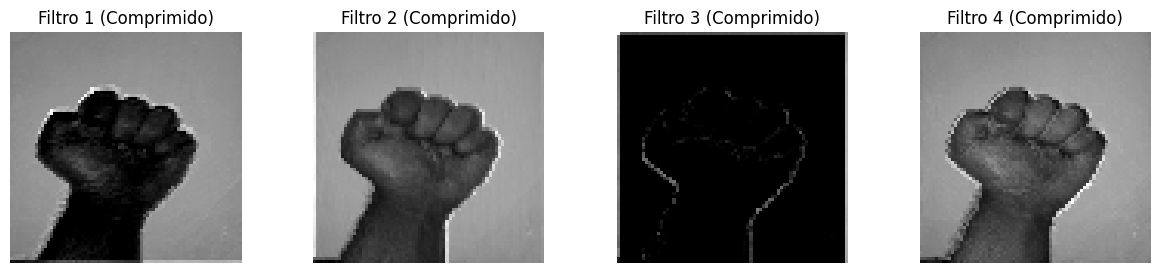


[CAMADA FLATTEN] O tensor agora possui formato: (1, 43808)
Toda a imagem 2D foi destruída e virou um vetor reto de milhares de números.
É assim que os neurônios recebem o dado (como se fosse uma planilha linear):


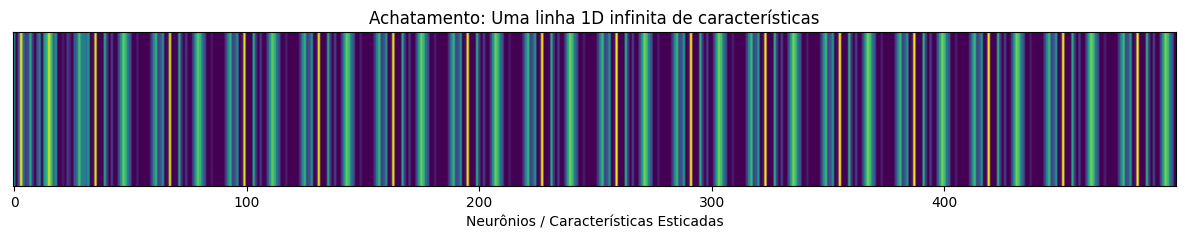

In [14]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

print("="*75)
print("O VERDADEIRO RAIO-X: EXTRAÇÃO DIRETA DO MODELO (API FUNCIONAL)")
print("="*75)

# ==============================================================================
# 1. CRIANDO UM MODELO TRANSPARENTE (API FUNCIONAL)
# ==============================================================================
# A API Funcional não tem o "bug" do Sequential. Ela liga os nós explicitamente.
entrada = tf.keras.layers.Input(shape=(150, 150, 3), name="Entrada_RGB")

# Camada 1: Pega o RGB e transforma em 16 matrizes (Filtros)
conv_1 = tf.keras.layers.Conv2D(16, 3, padding='same', activation='relu', name="Conv2D_1")(entrada)
pool_1 = tf.keras.layers.MaxPooling2D(name="Pooling_1")(conv_1)

# Camada 2: Pega as 16 matrizes e transforma em 32 matrizes menores
conv_2 = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu', name="Conv2D_2")(pool_1)
pool_2 = tf.keras.layers.MaxPooling2D(name="Pooling_2")(conv_2)

# A Ponte: Destrói as 32 matrizes 2D e cria uma única fita 1D
achatamento = tf.keras.layers.Flatten(name="Achatamento_1D")(pool_2)

# Construímos o Modelo Principal
modelo_transparente = tf.keras.Model(inputs=entrada, outputs=achatamento)

# Construímos o Modelo Extrator Oficial (O que você queria fazer!)
extrator = tf.keras.Model(
    inputs=modelo_transparente.input,
    outputs=[
        modelo_transparente.get_layer("Conv2D_1").output,
        modelo_transparente.get_layer("Pooling_1").output,
        modelo_transparente.get_layer("Achatamento_1D").output
    ]
)

# ==============================================================================
# 2. CARREGANDO A SUA IMAGEM DE TESTE
# ==============================================================================
# Substitua pelo nome de uma foto sua que já fez upload
nome_foto = "WhatsApp Image 2026-08-27 at 15.00.58.jpeg"

img_bruta = tf.keras.utils.load_img(nome_foto, target_size=(150, 150))
img_array = tf.keras.utils.img_to_array(img_bruta) / 255.0 # Normalizando na mão
img_tensor = tf.expand_dims(img_array, 0) # Lote de 1

# ==============================================================================
# 3. EXTRAINDO AS MATRIZES OFICIAIS DO MODELO
# ==============================================================================
saida_conv1, saida_pool1, saida_flatten = extrator.predict(img_tensor, verbose=0)

# ==============================================================================
# 4. RENDERIZAÇÃO MATEMÁTICA REAL
# ==============================================================================
plt.figure(figsize=(4, 4))
plt.imshow(img_bruta)
plt.title("A Foto Real (3 Canais RGB)")
plt.axis("off")
plt.show()

# 4.1 Visualizando a Conv2D (É 3D, não Cinza!)
# O formato será (1, 150, 150, 16). Vamos ver 4 desses 16 canais.
print(f"\n[CAMADA CONV2D_1] O tensor possui o formato geométrico: {saida_conv1.shape}")
print("A rede pegou a cor e separou em 16 mapas de características diferentes:")

fig, ax = plt.subplots(1, 4, figsize=(15, 3))
for i in range(4):
    ax[i].imshow(saida_conv1[0, :, :, i], cmap='gray') # Mostramos em cinza só para o olho humano ver o contraste
    ax[i].set_title(f"Filtro {i+1} da Conv2D")
    ax[i].axis("off")
plt.show()

# 4.2 Visualizando o MaxPooling (Redução 2D)
print(f"\n[CAMADA POOLING_1] O tensor encolheu para: {saida_pool1.shape}")
print("A imagem perdeu nitidez e caiu pela metade, mas a inteligência continuou:")

fig, ax = plt.subplots(1, 4, figsize=(15, 3))
for i in range(4):
    ax[i].imshow(saida_pool1[0, :, :, i], cmap='gray')
    ax[i].set_title(f"Filtro {i+1} (Comprimido)")
    ax[i].axis("off")
plt.show()

# 4.3 Visualizando o Flatten (A Morte do 2D)
print(f"\n[CAMADA FLATTEN] O tensor agora possui formato: {saida_flatten.shape}")
print("Toda a imagem 2D foi destruída e virou um vetor reto de milhares de números.")
print("É assim que os neurônios recebem o dado (como se fosse uma planilha linear):")

plt.figure(figsize=(15, 2))
# Mostramos um trecho (os primeiros 500 números) em formato de "código de barras"
trecho_flatten = saida_flatten[0, :500].reshape(1, -1)
plt.imshow(trecho_flatten, cmap='viridis', aspect='auto')
plt.title("Achatamento: Uma linha 1D infinita de características")
plt.yticks([]) # Tiramos o eixo Y pois não há mais altura!
plt.xlabel("Neurônios / Características Esticadas")
plt.show()

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PUXANDO UMA FOTO DIRETO DO DATASET OFICIAL
# ==============================================================================
# O pipeline dados_treino já está na memória do Colab desde o Dia 1
for imagens_lote, rotulos_lote in dados_treino.take(1):
    # Isolamos a primeira imagem do lote
    img_tensor = tf.expand_dims(imagens_lote[0], 0)
    img_bruta = imagens_lote[0].numpy().astype("uint8")
    gabarito = nomes_oficiais[rotulos_lote[0]]
    break

# ==============================================================================
# 2. MONTANDO A ARQUITETURA TRANSPARENTE
# ==============================================================================
entrada = tf.keras.layers.Input(shape=(150, 150, 3))
conv_1 = tf.keras.layers.Conv2D(16, 3, padding='same', activation='relu')(entrada)
pool_1 = tf.keras.layers.MaxPooling2D()(conv_1)
achatamento = tf.keras.layers.Flatten()(pool_1)

modelo_transparente = tf.keras.Model(inputs=entrada, outputs=achatamento)

# Criando o extrator para puxar os cabos lá de dentro
extrator = tf.keras.Model(
    inputs=modelo_transparente.input,
    outputs=[
        modelo_transparente.layers[1].output, # Saída da Conv2D
        modelo_transparente.layers[2].output, # Saída do Pooling
        modelo_transparente.layers[3].output  # Saída do Flatten
    ]
)

# ==============================================================================
# 3. A EXTRAÇÃO E RENDERIZAÇÃO TÉRMICA
# ==============================================================================
saida_conv1, saida_pool1, saida_flatten = extrator.predict(img_tensor, verbose=0)

plt.figure(figsize=(3, 3))
plt.imshow(img_bruta)
plt.title(f"Original do Dataset: {gabarito.upper()}")
plt.axis("off")
plt.show()

# A. MAPAS DE CALOR DA CONVOLUÇÃO
print(f"\n[CONV2D] O Tensor virou um volume: {saida_conv1.shape}")
print("As cores brilhantes mostram onde o filtro detectou padrões numéricos elevados:")

fig, ax = plt.subplots(1, 4, figsize=(15, 3))
for i in range(4):
    # cmap='viridis' aplica cores de radiação térmica (azul para zero, amarelo para alto)
    ax[i].imshow(saida_conv1[0, :, :, i], cmap='viridis')
    ax[i].set_title(f"Filtro Matemático {i+1}")
    ax[i].axis("off")
plt.show()

# B. MAPAS DE CALOR DO POOLING
print(f"\n[POOLING] A geometria caiu pela metade: {saida_pool1.shape}")
print("A imagem fica 'pixelada', mas as zonas de calor (padrões vitais) sobrevivem:")

fig, ax = plt.subplots(1, 4, figsize=(15, 3))
for i in range(4):
    ax[i].imshow(saida_pool1[0, :, :, i], cmap='viridis')
    ax[i].set_title(f"Filtro {i+1} Comprimido")
    ax[i].axis("off")
plt.show()

# C. O CÓDIGO DE BARRAS DO FLATTEN
print(f"\n[FLATTEN] O volume desmoronou em uma linha: {saida_flatten.shape}")

plt.figure(figsize=(15, 2))
trecho_flatten = saida_flatten[0, :500].reshape(1, -1)
plt.imshow(trecho_flatten, cmap='viridis', aspect='auto')
plt.title("Achatamento: Geometria destruída, pronta para a Rede Densa")
plt.yticks([])
plt.xlabel("As primeiras 500 características numéricas esticadas")
plt.show()

NameError: name 'dados_treino' is not defined

## Salvando modelo e treinando com nova base

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

print("="*75)
print("INCREMENTAL LEARNING: TREINAMENTO CUMULATIVO SEM PERDER A MEMÓRIA")
print("="*75)

# 1. DIVIDINDO O DATASET (Simulando a passagem do tempo)
# Vamos pegar nosso dados_treino original e fatiar no meio
total_lotes = tf.data.experimental.cardinality(dados_treino).numpy()
metade = total_lotes // 2

dados_mes_passado = dados_treino.take(metade)
dados_mes_atual = dados_treino.skip(metade)

print(f"Lotes antigos (Mês Passado): {metade}")
print(f"Lotes novos (Mês Atual): {total_lotes - metade}")


# 2. O TREINAMENTO ORIGINAL E O BACKUP
print("\n-> 1. Treinando o modelo com os dados antigos...")
# Vamos usar apenas 3 épocas para a demonstração ser rápida
historico_fase1 = modelo_cnn.fit(
    dados_mes_passado,
    validation_data=dados_val,
    epochs=3,
    verbose=1
)

print("\n-> 2. Salvando o 'cérebro' no HD e simulando o desligamento do servidor...")
# O formato .keras é o padrão oficial e moderno do TensorFlow
modelo_cnn.save("cerebro_industrial_v1.keras")
print("[SISTEMA] Modelo salvo com sucesso. Variáveis podem ser destruídas.")


# 3. O RETREINAMENTO CUMULATIVO (O Futuro)
print("\n" + "="*75)
print("UM MÊS DEPOIS: NOVOS DADOS CHEGARAM NA FÁBRICA")
print("="*75)

print("-> 3. Carregando o modelo salvo do HD...")
# load_model puxa a arquitetura, os pesos e o estado do otimizador
modelo_atualizado = tf.keras.models.load_model("cerebro_industrial_v1.keras")

# PROVA DE FOGO: A rede ainda sabe o que aprendeu mês passado?
print("-> Avaliando a memória retida antes de mostrar os dados novos:")
_, acuracia_retida = modelo_atualizado.evaluate(dados_val, verbose=0)
print(f"[MEMÓRIA] O modelo iniciou o dia com {acuracia_retida*100:.2f}% de acerto no simulado!")

print("\n-> 4. Retomando o treinamento apenas com os Dados Novos (Incremental)...")
# O fit() não zera a máquina. Ele continua a evolução matemática de onde parou.
historico_fase2 = modelo_atualizado.fit(
    dados_mes_atual,
    validation_data=dados_val,
    epochs=3,
    verbose=1
)

print("\n[SUCESSO] O modelo absorveu as novas imagens sem precisar treinar desde o início!")